#### Imports

In [106]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import copy
import random

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle
from sklearn.model_selection import train_test_split

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

Current device: cuda


In [107]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Master_Thesis\\utils.py'>

In [108]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [109]:
param_names_plots = ['Ozone (atm-cm)', 'Columnar Water Vapor (g/cm^2)', 'Aerosol Optical Depth (-)', 'Asymmetry Parameter (-)', 'Angstrom Exponent (-)',
                     'Single Scattering Albedo (-)', 'Solar Zenith Angle (deg)', 'View Zenith Angle (deg)', 'Relative Azimuth Angle (deg)']
param_names_plots_abb = ['O3', 'CWV', 'AOD', 'Asy. Param.', 'Ang. Exp.', 'SSA', 'SZA', 'VZA', 'RAA']

function_names_plots = ['Path Radiance', 'Direct Solar Irradiance', 'Diffuse Solar Irradiance', 'Spherical Albedo', 'Direct Transmittance', 'Diffuse Transmittance']
function_names_plots_abb = ['Path Rad.', 'Direct Irrad.', 'Diffuse Irrad.', 'Sph. Alb.', 'Direct Trans.', 'Diffuse Trans.']

In [110]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

# first split: train (80%) and temp (20%)
X_tr, X_temp, Y_tr, Y_temp = train_test_split(X, Y_resh, test_size=0.2, shuffle=True, random_state=42)

# second split: validation (10%) and test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=True, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print()
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Convolutional Neural Network Pipeline

<ol>
    <li><b>Model and Dataset Definition</b>: Encoder-Decoder architecture.</li>
    <li><b>Training/Validation</b>: train loop with validation to choose the best model.</li>
    <li><b>External Testing</b> of the best selected model.</li>
</ol>

In [111]:
class Dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [112]:
class Encoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, z_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [113]:
# 1st ARCHITECTURE: upsample convolutions to reconstruct the full spectrum from a low-dimensional latent space calculated from the 9 inputs
class SpectralDecoder1(nn.Module):
    def __init__(self, z_dim=128, channels=64):
        super().__init__()
        self.fc = nn.Linear(z_dim, channels * 64)

        # processing at low-res (64 --> 64 length)
        self.initial_conv = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=5, padding=2),
            nn.GroupNorm(8, 64),
            nn.SiLU()
        )

        # progressively upsample the sequence length
        # formula: Out = (In - 1) * stride - 2 * padding + kernel_size
        self.upsample_pipeline = nn.Sequential(
            # 64 -> 256 length
            nn.ConvTranspose1d(64, 32, kernel_size=6, stride=4, padding=1), 
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            
            # 256 -> 1024 length
            nn.ConvTranspose1d(32, 16, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(4, 16),
            nn.SiLU(),

            # 1024 -> 4096 length
            nn.ConvTranspose1d(16, 8, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(2, 8),
            nn.SiLU()
        )

        # final adjustment to hit exactly 4205 and map to 1 output channel
        self.final_conv = nn.Conv1d(8, 1, kernel_size=5, padding=2)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 64, 64)
        x = self.initial_conv(x)
        x = self.upsample_pipeline(x) # Shape is now (N, 8, 4096)
        
        # from 4096, use a tiny interpolation just to cover the last 109 points
        x = F.interpolate(x, size=4205, mode="linear", align_corners=False)
        
        x = self.final_conv(x).squeeze(1)
        return x
    
class EmulatorSet1(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()

        # 6 decoders, one for each radiative transfer function
        self.decoders = nn.ModuleList([
            SpectralDecoder1() for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        z = self.encoder(x)
        # return prediction as one tensor of shape (N, 6, 4205)
        return torch.stack([decoder(z) for decoder in self.decoders], dim=1)

In [114]:
# 2nd ARCHITECTURE: directly predict the PCA coefficients for each function from the latent space with MLP, without upsampling convolutions
class SpectralDecoder2(nn.Module):
    def __init__(self, z_dim=128, n_components=10):
        super().__init__()
        # map the latent space to the PCA coefficients
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, n_components) # output shape: (N, 10)
        )

    def forward(self, z):
        return self.net(z)

class EmulatorSet2(nn.Module):
    def __init__(self, n_components=10):
        super().__init__()
        self.encoder = Encoder()
        
        self.decoders = nn.ModuleList([
            SpectralDecoder2(z_dim=128, n_components=n_components) for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        z = self.encoder(x)
        # return prediction as one tensor of shape (N, 6, 10) - PCA coefficients for each function
        return torch.stack([decoder(z) for decoder in self.decoders], dim=1)

In [115]:
# 3rd ARCHITECTURE: add convolutional processing to the latent space before predicting PCA coefficients, to allow the model to learn local relationships in the structured sequence space
# technically wrong, as the PCA-reduced space doesn't have a true spatial structure, but it allows us to experiment with convolutional processing
class SpectralDecoder3(nn.Module):
    def __init__(self, z_dim=128, n_components=10, initial_length=128, channels=64):
        super().__init__()
        self.initial_length = initial_length
        self.channels = channels

        # map latent space to a structured sequence space (64 channels x 128 length)
        self.fc = nn.Linear(z_dim, channels * initial_length)

        # convolutions process features across the sequence dimension
        self.cnn = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=5, padding=2),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.GroupNorm(4, 16),
            nn.SiLU(),
        )

        # collapse the remaining sequence length down to exactly our 10 PCA dimensions
        # total flattened size: 16 channels * 128 length = 2048 features
        self.to_pca = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * initial_length, 256),
            nn.SiLU(),
            nn.Linear(256, n_components) # final output shape: (N, 10)
        )

    def forward(self, z):
        # shape transition: (N, 128) -> (N, 64 * 128)
        x = self.fc(z)
        
        # reshape to 1D CNN format: (N, 64, 128)
        x = x.view(z.size(0), self.channels, self.initial_length)
        
        # convolutions process local relationships: (N, 16, 128)
        x = self.cnn(x)
        
        # flatten and project to the 10 PCA components: (N, 10)
        pca_coefficients = self.to_pca(x)
        return pca_coefficients
    
class EmulatorSet3(nn.Module):
    def __init__(self, n_components=10):
        super().__init__()
        self.encoder = Encoder()
        
        self.decoders = nn.ModuleList([
            SpectralDecoder3(z_dim=128, n_components=n_components, initial_length=128, channels=64) 
            for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        z = self.encoder(x)
        # return prediction as one tensor of shape (N, 6, 10) - PCA coefficients for each function
        return torch.stack([decoder(z) for decoder in self.decoders], dim=1)

In [116]:
# 4th ARCHITECTURE: use squeeze and excite blocks to allow the model to learn which latent features are most important for each function, before predicting PCA coefficients

In [117]:
# quick model test
model = EmulatorSet1().to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32).to(device)
print("Input shape:", X_tr_tensor.shape)

with torch.no_grad():
    y_pred = model(X_tr_tensor)

# y is a tensor of shape (N, 6, 4205)
print("Output shape:", y_pred.shape)

summary(model, input_size=(1, globals.N_INPUTS))

Input shape: torch.Size([400, 9])
Output shape: torch.Size([400, 6, 4205])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 64]             640
              SiLU-2                [-1, 1, 64]               0
            Linear-3               [-1, 1, 128]           8,320
              SiLU-4               [-1, 1, 128]               0
            Linear-5               [-1, 1, 128]          16,512
              SiLU-6               [-1, 1, 128]               0
           Encoder-7               [-1, 1, 128]               0
            Linear-8              [-1, 1, 4096]         528,384
            Conv1d-9               [-1, 64, 64]          20,544
        GroupNorm-10               [-1, 64, 64]             128
             SiLU-11               [-1, 64, 64]               0
  ConvTranspose1d-12              [-1, 32, 256]          12,320
        GroupNorm-13        

Reduce and scale to prepare the datasets.

In [118]:
# scaled inputs
scale_type = "minmax"
x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(X_tr, X_val, scale_type=scale_type)

# scaled outputs
y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(Y_tr, Y_val, scale_type=scale_type)

# PCA-reduced outputs
pca_list, Y_tr_reduced, Y_val_reduced = utils.apply_pca(Y_tr, Y_val, n_components=10)

# scaled and PCA-reduced outputs
y_scalers_reduced, Y_tr_reduced_scaled, Y_val_reduced_scaled = utils.scale_output_data(Y_tr_reduced, Y_val_reduced, scale_type=scale_type)

# prepare test set with the same transformations
X_test_scaled = x_scaler.transform(X_test)
Y_test_scaled = np.zeros_like(Y_test)
Y_test_reduced = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, 10))
Y_test_reduced_scaled = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, 10))

for i in range(globals.N_FUNCTIONS):
    Y_test_scaled[:, i, :] = y_scalers[i].transform(Y_test[:, i, :])

for i in range(globals.N_FUNCTIONS):
    Y_test_reduced[:, i, :] = pca_list[i].transform(Y_test[:, i, :])
    Y_test_reduced_scaled[:, i, :] = y_scalers_reduced[i].transform(Y_test_reduced[:, i, :])

---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------

In [119]:
print("Train scaled min:", Y_tr_scaled.min())
print("Val scaled min:", Y_val_scaled.min())

print(np.sum(Y_tr_scaled == 0))
print(np.sum(Y_val_scaled == 0))

Train scaled min: 0.0
Val scaled min: -0.16481781
103253
9799


Using MRE as the loss function in this scenario would not be desirable, as the training loss would explode to very high values due to the high amount of training values near zero.

In [120]:
def create_datasets(X_tr, X_val, Y_tr, Y_val, X_test, Y_test, verbose=True):
    # define datasets and dataloaders for non-reduced version
    train_ds = Dataset(X_tr, Y_tr)
    val_ds = Dataset(X_val, Y_val)
    test_ds = Dataset(X_test, Y_test)

    if verbose:
        print("Train dataset length:", len(train_ds))
        print("Val dataset length:", len(val_ds))
        print("Test dataset length:", len(test_ds))

        # get item check
        x, y = train_ds.__getitem__(0)
        print("Input shape:", x.shape)
        print("Output shape:", y.shape)
        print()

    return train_ds, val_ds, test_ds

In [121]:
# unscaled and non-reduced version
train_ds, val_ds, test_ds = create_datasets(X_tr, X_val, Y_tr, Y_val, X_test, Y_test)

# scaled and non-reduced version
train_ds_scaled, val_ds_scaled, test_ds_scaled = create_datasets(X_tr_scaled, X_val_scaled, Y_tr_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)

# unscaled and PCA-reduced version
train_ds_reduced, val_ds_reduced, test_ds_reduced = create_datasets(X_tr, X_val, Y_tr_reduced, Y_val_reduced, X_test, Y_test_reduced)

# scaled and PCA-reduced version
train_ds_reduced_scaled, val_ds_reduced_scaled, test_ds_reduced_scaled = create_datasets(X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled, Y_val_reduced_scaled, X_test_scaled, Y_test_reduced_scaled)

Train dataset length: 400
Val dataset length: 50
Test dataset length: 50
Input shape: torch.Size([9])
Output shape: torch.Size([6, 4205])

Train dataset length: 400
Val dataset length: 50
Test dataset length: 50
Input shape: torch.Size([9])
Output shape: torch.Size([6, 4205])

Train dataset length: 400
Val dataset length: 50
Test dataset length: 50
Input shape: torch.Size([9])
Output shape: torch.Size([6, 10])

Train dataset length: 400
Val dataset length: 50
Test dataset length: 50
Input shape: torch.Size([9])
Output shape: torch.Size([6, 10])



In [122]:
config = {
    "train_ds": train_ds_reduced_scaled,
    "val_ds": val_ds_reduced_scaled,
    "test_ds": test_ds_reduced_scaled,
    "scaled": True,
    "reduced": True,
    "pca_list": pca_list,
    "batch_size": 4,
}
if config["reduced"] and config["scaled"]:
    config["y_scalers"] = y_scalers_reduced
else:
    config["y_scalers"] = y_scalers

train_dl = DataLoader(config["train_ds"], batch_size=config["batch_size"], shuffle=True)
val_dl = DataLoader(config["val_ds"], batch_size=config["batch_size"])
test_dl = DataLoader(config["test_ds"], batch_size=config["batch_size"])

In [123]:
class MRELoss(nn.Module):
    def __init__(self, wavelengths, epsilon=1e-8, useMask=False):
        super().__init__()
        self.epsilon = epsilon
        self.wavelengths = wavelengths
        self.useMask = useMask

    def forward(self, pred, target):
        if self.useMask:
            mask = utils.build_mask(self.wavelengths)
            relative_error = torch.abs(pred[:, :, mask] - target[:, :, mask]) / (torch.abs(target[:, :, mask]) + self.epsilon)
        else:
            relative_error = torch.abs(pred - target) / (torch.abs(target) + self.epsilon)
        return torch.mean(relative_error)

In [124]:
def calculate_metrics(config, y_pred, Y_batch, wavelengths):
    if config["scaled"] or config["reduced"]:
        # prepare tensors to hold the restored predictions and targets in original space
        y_pred_og_shape = torch.zeros((y_pred.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred.device)
        y_true_og_shape = torch.zeros((Y_batch.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=Y_batch.device)

        # inverse transform the scaling and PCA to get back to original space if needed
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred[:, i, :].cpu().detach().numpy()
            y_true_restored = Y_batch[:, i, :].cpu().detach().numpy()
            if config["scaled"]:
                y_pred_restored = config["y_scalers"][i].inverse_transform(y_pred_restored)
                y_true_restored = config["y_scalers"][i].inverse_transform(y_true_restored)
            if config["reduced"]:
                y_pred_restored = config["pca_list"][i].inverse_transform(y_pred_restored)
                y_true_restored = config["pca_list"][i].inverse_transform(y_true_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_og_shape.device)
            y_true_og_shape[:, i, :] = torch.from_numpy(y_true_restored).to(y_true_og_shape.device)

        batch_train_mre_unscaled = utils.mre_score(y_pred_og_shape.cpu().detach().numpy(), y_true_og_shape.cpu().detach().numpy(), wavelengths)
    else:
        batch_train_mre_unscaled = utils.mre_score(y_pred.cpu().detach().numpy(), Y_batch.cpu().detach().numpy(), wavelengths)

    return batch_train_mre_unscaled

In [125]:
# train loop configurations
n_epochs = 100
model = EmulatorSet3().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.L1Loss()
history = defaultdict(list)

# scheduler setup for learning rate reduction on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.2,      # cut LR by 5x when stalling
    patience=5,      # wait 5 epochs before cutting
)

# early stopping setup
patience = 25
best_val_mre = float("inf")
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

epsilon = 1e-8

for epoch in range(n_epochs):
    # ==================== TRAINING PHASE ====================
    model.train()
    epoch_train_loss = 0.0          # mae in transformed space
    epoch_train_mre_unscaled = 0.0  # for interpretability, not used in backprop, calculated in original space after inverse transforms

    train_tqdm = tqdm(train_dl, desc=f"Epoch {epoch+1}/{n_epochs} [Train]")
    for X_batch, Y_batch in train_tqdm:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        
        loss = 0.0
        batch_train_mre_unscaled = 0.0

        # loss calculation
        loss += criterion(y_pred, Y_batch)

        loss.backward()
        optimizer.step()

        # metrics calculation in original space for interpretability
        batch_train_mre_unscaled += calculate_metrics(config, y_pred, Y_batch, wavelengths)

        # track metrics weighted by batch size to account for varying batches
        epoch_train_loss += loss.item() * X_batch.size(0)
        epoch_train_mre_unscaled += batch_train_mre_unscaled * X_batch.size(0)
        train_tqdm.set_postfix({
            "loss": loss.item(),
            "mre_unscaled": batch_train_mre_unscaled,
        })

    # average metrics over the entire dataset
    epoch_train_loss /= len(config["train_ds"])
    epoch_train_mre_unscaled /= len(config["train_ds"])
    history["train_loss"].append(epoch_train_loss)
    history["train_mre_unscaled"].append(epoch_train_mre_unscaled)

    # ==================== VALIDATION PHASE ====================
    model.eval()
    epoch_val_loss = 0.0
    epoch_val_mre_unscaled = 0.0
    val_tqdm = tqdm(val_dl, desc=f"Epoch {epoch+1}/{n_epochs} [Val]")
    with torch.no_grad():
        for X_batch, Y_batch in val_tqdm:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            y_pred = model(X_batch)
            
            loss = 0.0
            batch_val_mre_unscaled = 0.0

            loss += criterion(y_pred, Y_batch)

            batch_val_mre_unscaled += calculate_metrics(config, y_pred, Y_batch, wavelengths)

            epoch_val_loss += loss.item() * X_batch.size(0)
            epoch_val_mre_unscaled += batch_val_mre_unscaled * X_batch.size(0)

            val_tqdm.set_postfix({
                "loss": loss.item(),
                "mre_unscaled": batch_val_mre_unscaled,
            })
            
    epoch_val_loss /= len(config["val_ds"])
    epoch_val_mre_unscaled /= len(config["val_ds"])
    scheduler.step(epoch_val_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_mre_unscaled"].append(epoch_val_mre_unscaled)

    print(f"--- Epoch {epoch+1} Summary ---")
    print(f"Train Loss (MAE): {epoch_train_loss:.6f}")
    print(f"Train MRE (Unscaled): {epoch_train_mre_unscaled:.6f}")
    print(f"Val Loss (MAE):   {epoch_val_loss:.6f}")
    print(f"Val MRE (Unscaled): {epoch_val_mre_unscaled:.6f}")

    # ==================== EARLY STOPPING LOGIC ====================
    if epoch_val_mre_unscaled < best_val_mre:
        best_val_mre = epoch_val_mre_unscaled
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("--> Validation MRE decreased. Saving best model weights!")
    else:
        patience_counter += 1
        print(f"--> No improvement in val MRE. Patience counter: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print("\n!!! Early stopping triggered. Training halted. !!!")
            break
    print()

# reload the best weights found during the run before evaluating on test set
model.load_state_dict(best_model_wts)
print("Loaded best model weights for subsequent testing.")

Epoch 1/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 148.53it/s, loss=0.0841, mre_unscaled=0.0993]


--- Epoch 1 Summary ---
Train Loss (MAE): 0.164884
Train MRE (Unscaled): 0.385171
Val Loss (MAE):   0.117743
Val MRE (Unscaled): 0.163434
--> Validation MRE decreased. Saving best model weights!



Epoch 2/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 164.08it/s, loss=0.0745, mre_unscaled=0.0848]


--- Epoch 2 Summary ---
Train Loss (MAE): 0.097789
Train MRE (Unscaled): 0.112981
Val Loss (MAE):   0.083197
Val MRE (Unscaled): 0.079851
--> Validation MRE decreased. Saving best model weights!



Epoch 3/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 149.24it/s, loss=0.0698, mre_unscaled=0.0904]


...

--- Epoch 98 Summary ---
Train Loss (MAE): 0.003313
Train MRE (Unscaled): 0.002282
Val Loss (MAE):   0.008378
Val MRE (Unscaled): 0.006819
--> No improvement in val MRE. Patience counter: 12/25



Epoch 99/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 155.67it/s, loss=0.00507, mre_unscaled=0.00778]


--- Epoch 99 Summary ---
Train Loss (MAE): 0.003311
Train MRE (Unscaled): 0.002285
Val Loss (MAE):   0.008380
Val MRE (Unscaled): 0.006842
--> No improvement in val MRE. Patience counter: 13/25



Epoch 100/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 157.56it/s, loss=0.00505, mre_unscaled=0.00777]

--- Epoch 100 Summary ---
Train Loss (MAE): 0.003280
Train MRE (Unscaled): 0.002247
Val Loss (MAE):   0.008374
Val MRE (Unscaled): 0.006830
--> No improvement in val MRE. Patience counter: 14/25

Loaded best model weights for subsequent testing.


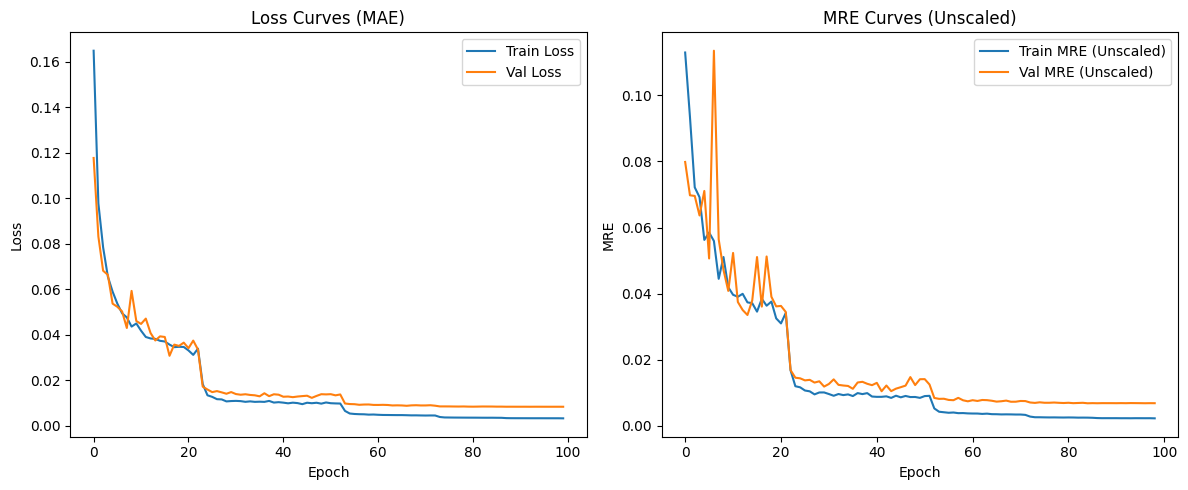

In [126]:
# history plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves (MAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_mre_unscaled"][1:], label="Train MRE (Unscaled)")
plt.plot(history["val_mre_unscaled"][1:], label="Val MRE (Unscaled)")
plt.title("MRE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MRE")
plt.legend()

plt.tight_layout()
plt.show()

In [127]:
# test on test set
model.eval()
test_loss = 0.0
test_mre_unscaled = 0.0
test_tqdm = tqdm(test_dl, desc="Testing")
with torch.no_grad():
    for X_batch, Y_batch in test_tqdm:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        y_pred = model(X_batch)
        
        loss = 0.0
        batch_test_mre_unscaled = 0.0

        loss += criterion(y_pred, Y_batch)
        batch_test_mre_unscaled += calculate_metrics(config, y_pred, Y_batch, wavelengths)
            
        test_loss += loss.item() * X_batch.size(0)
        test_mre_unscaled += batch_test_mre_unscaled * X_batch.size(0)
        
        test_tqdm.set_postfix({
            "loss": loss.item(),
            "mre_unscaled": batch_test_mre_unscaled,
        })
        
print(f"\nFinal Test Loss: {test_loss / len(config['test_ds']):.6f}")
print(f"Final Test MRE (Unscaled): {test_mre_unscaled / len(config['test_ds']):.6f}")

Testing: 100%|██████████| 13/13 [00:00<00:00, 150.27it/s, loss=0.00476, mre_unscaled=0.00288]


Final Test Loss: 0.011310
Final Test MRE (Unscaled): 0.006645


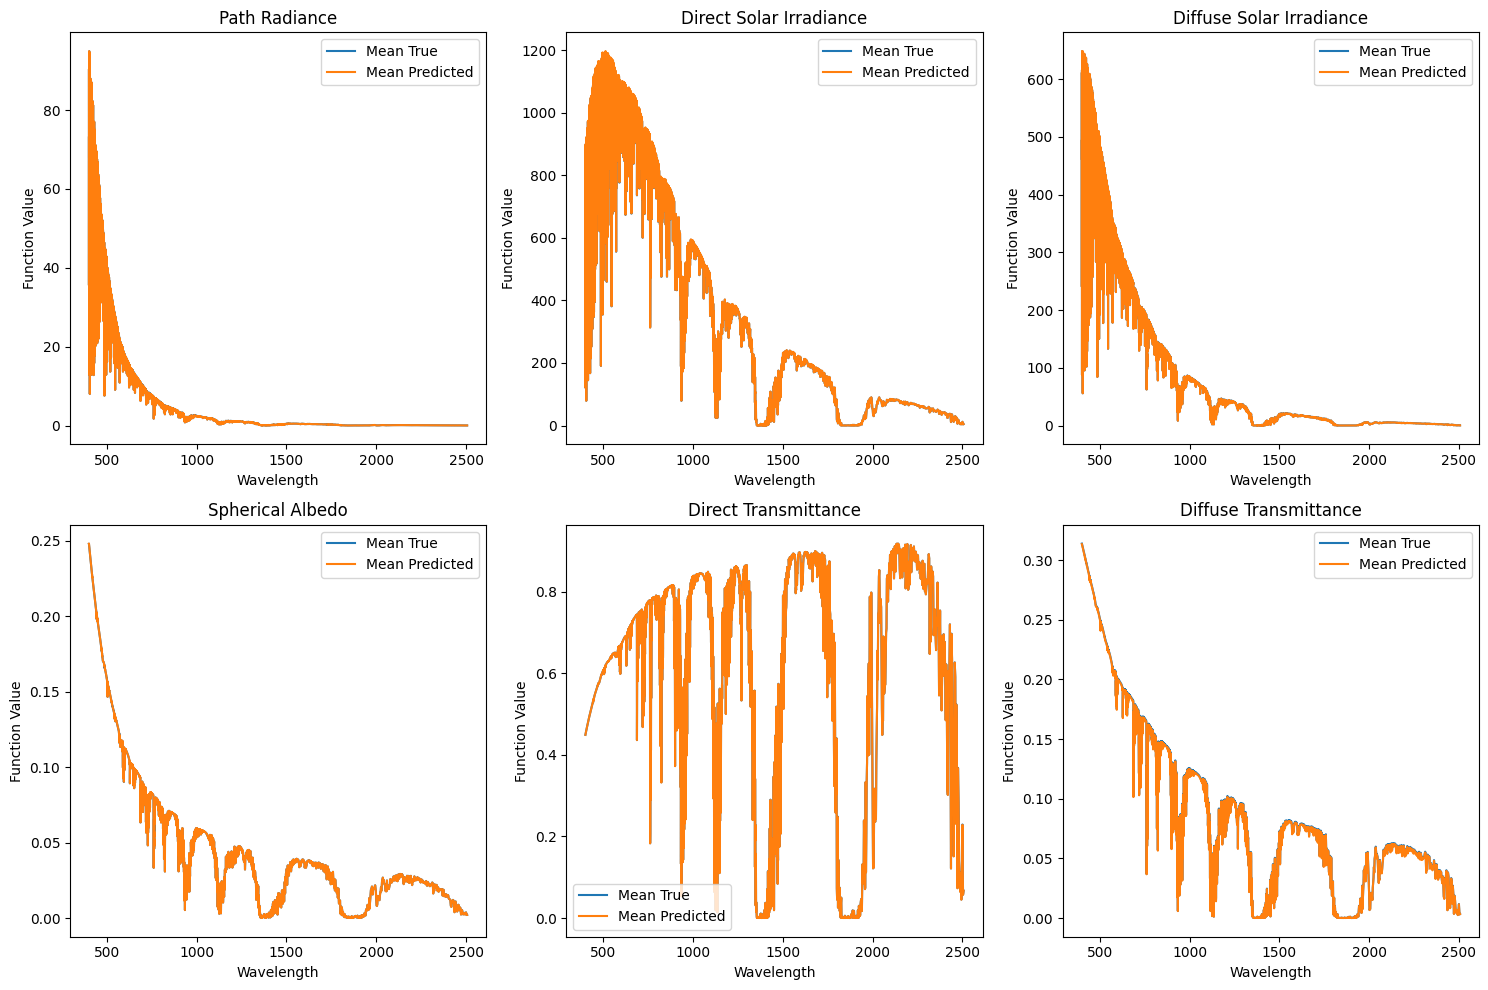

In [128]:
# predict on test set for visualization
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred = model(X_test_tensor)
    if config["scaled"] or config["reduced"]:
        y_pred_og_shape = torch.zeros((y_pred.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred[:, i, :].cpu().detach().numpy()
            if config["scaled"]:
                y_pred_restored = config["y_scalers"][i].inverse_transform(y_pred_restored)
            if config["reduced"]:
                y_pred_restored = config["pca_list"][i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred.device)
        y_pred = y_pred_og_shape

plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(Y_test[:, i, :], axis=0), label="Mean True")
    plt.plot(wavelengths, np.mean(y_pred[:, i, :].squeeze(0).cpu().numpy(), axis=0), label="Mean Predicted")
    plt.title(f"{function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()